<a href="https://colab.research.google.com/github/Silvinharl/MVP_Machine_Learning/blob/main/MVP_Voos_ANAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP - Predição de Atrasos em Voos Comerciais**






## *Parte I*

### **1. Definição do Problema**

O transporte aéreo é um setor altamente dependente de planejamento operacional e pontualidade. A ocorrência de atrasos impacta passageiros, companhias aéreas, aeroportos e toda a cadeia logística associada.

Neste trabalho será desenvolvido um modelo de Machine Learning capaz de prever se um voo apresentará atraso na chegada, utilizando informações disponíveis durante o planejamento operacional do voo.

O problema será tratado como uma tarefa de classificação supervisionada, onde a variável-alvo indicará se o voo chegou atrasado ou não.

O objetivo é avaliar se características como companhia aérea, aeroporto de origem, aeroporto de destino, capacidade da aeronave e horário previsto de partida possuem poder preditivo suficiente para identificar padrões associados aos atrasos.

Esse problema é adequado para Machine Learning porque existem exemplos históricos rotulados, permitindo que algoritmos aprendam padrões presentes nos dados e realizem previsões sobre novos voos.


### **2. Carregamento dos Dados**

Os dados utilizados neste trabalho foram obtidos a partir da base pública VRA (Voo Regular Ativo), disponibilizada pela Agência Nacional de Aviação Civil (ANAC), disponível em https://www.anac.gov.br/acesso-a-informacao/dados-abertos/areas-de-atuacao/voos-e-operacoes-aereas/voo-regular-ativo-vra/voo-regular-ativo-vra. A base original contém dados de vôos ocorridos a partir do ano 2000. Para este MVP, foi utilizado um corte inicial de janeiro a março de 2025.

Para garantir a reprodutibilidade do experimento, o dataset foi armazenado em um repositório público do GitHub e é carregado diretamente por URL.

Em relação ao dataset original (disponível no site da ANAC), foram preservadas apenas as colunas relevantes para o problema proposto. Os atributos não utilizados foram removidos do arquivo original antes do carregamento no repositório.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/Silvinharl/MVP_Machine_Learning/refs/heads/main/dados/VRA_2025_01_C.csv"

df = pd.read_csv(url, sep=';')

print(df.shape)
df.head()

(250833, 6)


,Sigla Aerea,NumeroAssentos,Origem,Destino,Partida Prevista,Situacao Chegada
0,AAL,295,SBGL,KMIA,01/01/2025 23:55,Pontual
1,AAL,295,KMIA,SBGL,01/01/2025 01:10,Antecipado
2,AAL,318,SBGR,KMIA,01/01/2025 00:30,Antecipado
3,AAL,288,KMIA,SBGR,01/01/2025 23:50,Pontual
4,AAL,318,KMIA,SBGR,01/01/2025 20:50,Pontual


A base possui 250.833 registros e 6 atributos:

- Sigla Aerea
- NumeroAssentos
- Origem
- Destino
- Partida Prevista
- Situacao Chegada

#### 3.1 Descrição das Variáveis

| Variável | Descrição |
|-----------|-----------|
| Sigla Aerea | Companhia aérea responsável pelo voo |
| NumeroAssentos | Capacidade de assentos da aeronave |
| Origem | Aeroporto de origem do voo |
| Destino | Aeroporto de destino do voo |
| Partida Prevista | Data e horário previstos para a decolagem |
| Situacao Chegada | Classificação do horário de chegada do voo |

#### 3.2 Tipos das Variáveis

Observa-se que a variável NumeroAssentos possui natureza numérica, enquanto as demais variáveis são categóricas ou textuais.

A variável Partida Prevista será posteriormente convertida para o formato datetime, permitindo a extração de atributos temporais relevantes para a modelagem.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250833 entries, 0 to 250832
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Sigla Aerea       250833 non-null  object
 1   NumeroAssentos    250833 non-null  int64 
 2   Origem            250833 non-null  object
 3   Destino           250833 non-null  object
 4   Partida Prevista  244261 non-null  object
 5   Situacao Chegada  235988 non-null  object
dtypes: int64(1), object(5)
memory usage: 11.5+ MB


#### 3.3 Valores Ausentes

In [3]:
df.isnull().sum()

,0
Sigla Aerea,0
NumeroAssentos,0
Origem,0
Destino,0
Partida Prevista,6572
Situacao Chegada,14845


A verificação de valores ausentes identificou 6.572 registros sem informação de Partida Prevista e 14.845 registros sem informação de Situacao Chegada.

Como ambas as variáveis são fundamentais para o desenvolvimento do modelo, esses registros serão removidos durante a etapa de preparação dos dados.

#### 3.4 Distribuição da Situação de Chegada (variável-alvo)

In [4]:
df['Situacao Chegada'].value_counts()

,count
Situacao Chegada,
Antecipado,146411
Pontual,69159
Atraso 30-60,11429
Atraso 60-120,5611
Atraso 120-240,2283
Atraso > 240,1095


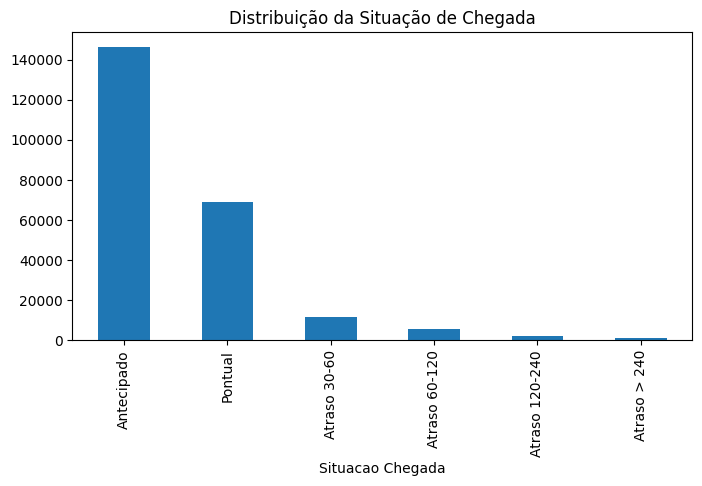

In [5]:
import matplotlib.pyplot as plt

df['Situacao Chegada'].value_counts().plot(
    kind='bar',
    figsize=(8,4)
)

plt.title('Distribuição da Situação de Chegada')
plt.show()

A maioria dos voos foi classificada como Antecipado ou Pontual.

As categorias de atraso representam uma parcela menor da base de dados, indicando um cenário naturalmente desbalanceado.

Essa característica deverá ser considerada durante a avaliação dos modelos, utilizando métricas além da acurácia.

### **4. Preparação dos dados**

#### 4.1 Remoção dos registros incompletos

In [6]:
df = df.dropna()

print(df.shape)

(235988, 6)


Nesta etapa foram realizados os tratamentos necessários para adequar os dados ao processo de modelagem.

Inicialmente, foram avaliados os registros que apresentavam valores ausentes nas variáveis Partida Prevista ou Situacao Chegada.

Como ambas as variáveis são fundamentais para o problema proposto e o total de regristros a serem eliminados não representaria uma grande parcela do total de entradas, optou-se pela remoção desses registros.

Dos 250.083 registros iniciais, foram mantidos 235.988 registros após a remoção dos que continham as colunas Partida Prevista ou Situacao Chegada sem informação.


In [7]:
df.isnull().sum()

,0
Sigla Aerea,0
NumeroAssentos,0
Origem,0
Destino,0
Partida Prevista,0
Situacao Chegada,0


#### 4.2 Variável-alvo
Para transformar o problema em uma tarefa de classificação binária, foi criada a variável atrasado.

A variável recebeu valor:

- 0 para voos classificados como Pontual ou Antecipado;
- 1 para voos classificados em qualquer categoria de atraso.

Essa transformação simplifica a modelagem e permite avaliar a capacidade dos algoritmos em identificar voos com potencial de atraso.

In [8]:
df['atrasado'] = df['Situacao Chegada'].apply(
    lambda x: 1 if 'Atraso' in str(x) else 0
)

df['atrasado'].value_counts()

,count
atrasado,
0,215570
1,20418


#### 4.3 Engenharia de Atributos

A variável Partida Prevista foi convertida para o formato datetime.

A partir dela foram extraídos novos atributos temporais:

- hora_partida: hora prevista para a decolagem;
- minuto_partida: minuto previsto para a decolagem;
- dia_semana: dia da semana da operação, codificado de 0 (segunda-feira) a 6 (domingo);
- mes: mês da operação.

Essas variáveis foram criadas com o objetivo de capturar possíveis padrões temporais associados aos atrasos.

In [9]:
df['Partida Prevista'] = pd.to_datetime(
    df['Partida Prevista'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)
print(df['Partida Prevista'].dtype)
df['hora_partida'] = df['Partida Prevista'].dt.hour
df['minuto_partida'] = df['Partida Prevista'].dt.minute
df['dia_semana'] = df['Partida Prevista'].dt.dayofweek
df['mes'] = df['Partida Prevista'].dt.month

datetime64[ns]


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 235988 entries, 0 to 250832
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sigla Aerea       235988 non-null  object        
 1   NumeroAssentos    235988 non-null  int64         
 2   Origem            235988 non-null  object        
 3   Destino           235988 non-null  object        
 4   Partida Prevista  235988 non-null  datetime64[ns]
 5   Situacao Chegada  235988 non-null  object        
 6   atrasado          235988 non-null  int64         
 7   hora_partida      235988 non-null  int32         
 8   minuto_partida    235988 non-null  int32         
 9   dia_semana        235988 non-null  int32         
 10  mes               235988 non-null  int32         
dtypes: datetime64[ns](1), int32(4), int64(2), object(4)
memory usage: 18.0+ MB


In [11]:
df[['Partida Prevista',
    'hora_partida',
    'minuto_partida',
    'dia_semana',
    'mes']].head()

,Partida Prevista,hora_partida,minuto_partida,dia_semana,mes
0,2025-01-01 23:55:00,23,55,2,1
1,2025-01-01 01:10:00,1,10,2,1
2,2025-01-01 00:30:00,0,30,2,1
3,2025-01-01 23:50:00,23,50,2,1
4,2025-01-01 20:50:00,20,50,2,1


### **5. Análise dos Atributos**

Após a preparação dos dados, foi realizada uma análise exploratória das variáveis selecionadas para a modelagem.

O objetivo é identificar possíveis padrões entre os atributos disponíveis e a ocorrência de atrasos, auxiliando na compreensão do problema e na interpretação futura dos modelos.

#### 5.1 Análise 1 — Companhias aéreas

In [12]:
companhias = (
    df.groupby('Sigla Aerea')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

companhias.head(15)

,atrasado
Sigla Aerea,
CKS,1.000000
HFY,0.800000
CJT,0.750000
GXA,0.714286
GTI,0.668874
LYC,0.666667
LCO,0.653913
NCR,0.628571
LAE,0.593548


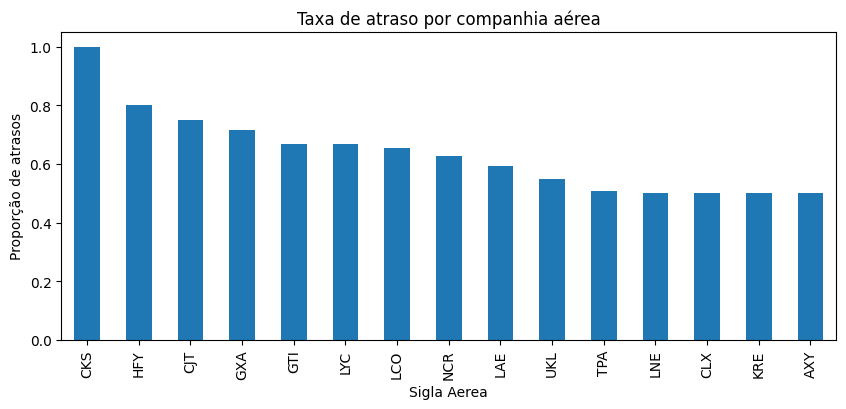

In [13]:
import matplotlib.pyplot as plt

companhias.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Taxa de atraso por companhia aérea')
plt.ylabel('Proporção de atrasos')
plt.show()

#### 5.2 Análise 2 — Hora da partida

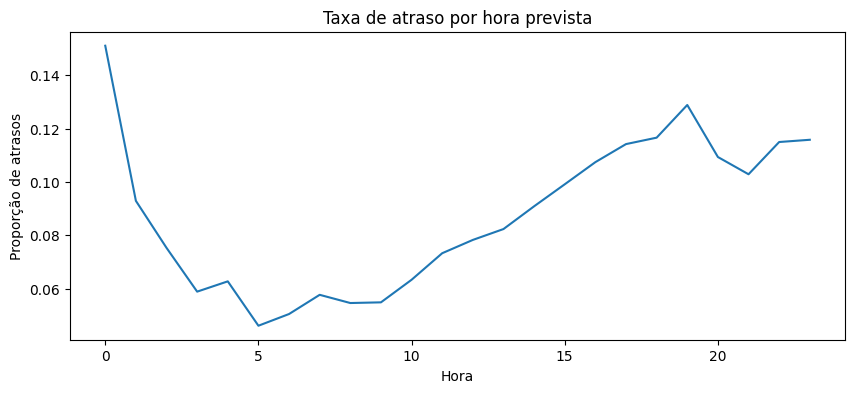

In [14]:
hora = (
    df.groupby('hora_partida')['atrasado']
      .mean()
)

hora.plot(
    figsize=(10,4)
)

plt.title('Taxa de atraso por hora prevista')
plt.ylabel('Proporção de atrasos')
plt.xlabel('Hora')
plt.show()

#### 5.3 Análise 3 — Aeroportos de origem

In [15]:
origem = (
    df.groupby('Origem')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

origem.head(15)

,atrasado
Origem,
KSEA,1.000000
SANT,1.000000
SDSC,1.000000
TJSJ,1.000000
TLPL,1.000000
SKBQ,1.000000
VTBS,1.000000
KPHX,0.875000
SLCB,0.758621


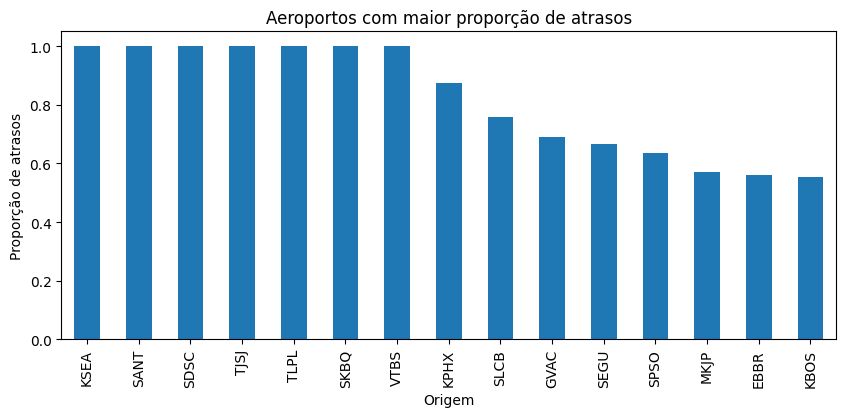

In [16]:
origem.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Aeroportos com maior proporção de atrasos')
plt.ylabel('Proporção de atrasos')
plt.show()

#### 5.4 Análise 4 — Aeroportos de destino

In [17]:
destino = (
    df.groupby('Destino')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

destino.head(15)

,atrasado
Destino,
KTPA,1.000000
MNMG,1.000000
KSEA,1.000000
SKPE,1.000000
ZBTJ,1.000000
TJSJ,1.000000
MKJP,0.857143
SANT,0.800000
GVAC,0.709091


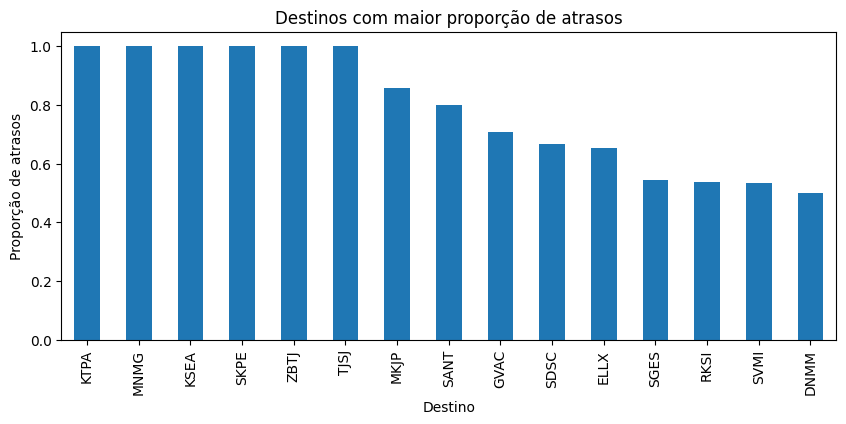

In [18]:
destino.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Destinos com maior proporção de atrasos')
plt.ylabel('Proporção de atrasos')
plt.show()

#### 5.5 Refinamento da Análise

A análise inicial identificou companhias aéreas e aeroportos com taxas extremamente elevadas de atraso, chegando a 100% em alguns casos.

Entretanto, observou-se que parte desses resultados estava associada a grupos com quantidade muito reduzida de observações.

Nessas situações, uma única ocorrência de atraso pode produzir taxas artificialmente elevadas, comprometendo a interpretação dos resultados.

Por esse motivo, foi realizada uma análise complementar considerando também a quantidade de voos observados para cada companhia aérea e aeroporto.

In [19]:
companhias_stats = (
    df.groupby('Sigla Aerea')
      .agg(
          taxa_atraso=('atrasado','mean'),
          qtd_voos=('atrasado','count')
      )
)

companhias_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Sigla Aerea,,
CKS,1.000000,2
HFY,0.800000,10
CJT,0.750000,8
GXA,0.714286,14
GTI,0.668874,302
LYC,0.666667,3
LCO,0.653913,575
NCR,0.628571,35
LAE,0.593548,155


In [20]:
origem_stats = (
    df.groupby('Origem')
      .agg(
          taxa_atraso=('atrasado','mean'),
          qtd_voos=('atrasado','count')
      )
)

origem_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Origem,,
KSEA,1.000000,1
SANT,1.000000,3
SDSC,1.000000,2
TJSJ,1.000000,2
TLPL,1.000000,1
SKBQ,1.000000,1
VTBS,1.000000,3
KPHX,0.875000,8
SLCB,0.758621,58


In [21]:
destino_stats = (
    df.groupby('Destino')
      .agg(
          taxa_atraso=('atrasado','mean'),
          qtd_voos=('atrasado','count')
      )
)

destino_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Destino,,
KTPA,1.000000,1
MNMG,1.000000,1
KSEA,1.000000,1
SKPE,1.000000,1
ZBTJ,1.000000,1
TJSJ,1.000000,2
MKJP,0.857143,7
SANT,0.800000,5
GVAC,0.709091,110


#### 5.6 Análise com Controle de Frequência

A análise complementar confirmou que parte dos resultados observados inicialmente estava associada a grupos com número reduzido de observações.

Companhias aéreas e aeroportos que apresentavam taxas de atraso extremamente elevadas frequentemente possuíam apenas alguns poucos voos registrados na base de dados.

Para reduzir o impacto de flutuações ocasionais e aumentar a confiabilidade das interpretações, foi aplicado um critério mínimo de frequência, considerando apenas grupos com pelo menos 100 voos registrados.

Essa abordagem permitiu identificar padrões mais consistentes e representativos do comportamento operacional observado no período analisado.

In [22]:
companhias_filtradas = companhias_stats[
    companhias_stats['qtd_voos'] >= 100
]

companhias_filtradas.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Sigla Aerea,,
GTI,0.668874,302
LCO,0.653913,575
LAE,0.593548,155
TPA,0.508850,226
CLX,0.500000,206
LTG,0.488889,585
KAL,0.428571,182
BOV,0.386905,336
FBZ,0.361793,937


In [23]:
origem_filtrada = origem_stats[
    origem_stats['qtd_voos'] >= 100
]

origem_filtrada.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Origem,,
GVAC,0.690265,113
EBBR,0.559633,109
SEQM,0.391566,166
KMIA,0.345934,1402
SBUY,0.280576,139
KDFW,0.269737,152
SLVR,0.234043,188
KIAH,0.220994,181
LPPT,0.209354,1347


In [24]:
destino_filtrado = destino_stats[
    destino_stats['qtd_voos'] >= 100
]

destino_filtrado.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Destino,,
GVAC,0.709091,110
KDFW,0.456954,151
SEQM,0.394636,261
LTFM,0.290123,162
KATL,0.252830,265
EDDF,0.247093,344
KMIA,0.237465,1057
SBUY,0.230769,143
SLVR,0.225806,248


Reconhece-se que categorias muito raras podem introduzir ruído e favorecer padrões específicos de treinamento, representando uma potencial limitação do modelo, entretanto, essas categorias foram mantidas na modelagem por representarem observações válidas da base de dados.

### **6. Preparação para Modelagem**

Após a etapa de análise exploratória e engenharia de atributos, os dados foram preparados para utilização nos algoritmos de Machine Learning.

A variável-alvo utilizada foi `atrasado`, criada durante a etapa de preparação dos dados.

As variáveis categóricas foram transformadas para formato numérico por meio de codificação apropriada, permitindo sua utilização pelos algoritmos de classificação.

Por fim, os dados foram divididos em conjuntos de treinamento e teste para avaliação do desempenho dos modelos.

#### 6.1 Definição de x e y

In [25]:
X = df[
    [
        'Sigla Aerea',
        'NumeroAssentos',
        'Origem',
        'Destino',
        'hora_partida',
        'minuto_partida',
        'dia_semana',
        'mes'
    ]
]

y = df['atrasado']
print(X.shape)
print(y.shape)

(235988, 8)
(235988,)


In [26]:
X.dtypes

,0
Sigla Aerea,object
NumeroAssentos,int64
Origem,object
Destino,object
hora_partida,int32
minuto_partida,int32
dia_semana,int32
mes,int32


#### 6.2 One-Hot Encoding
As variáveis Sigla Aerea, Origem e Destino possuem natureza categórica e não podem ser utilizadas diretamente por alguns algoritmos de Machine Learning.

Para resolver esse problema foi utilizada a técnica One-Hot Encoding, que transforma cada categoria em uma variável binária.

Essa abordagem permite representar informações categóricas de forma adequada sem introduzir relações artificiais entre categorias.

In [27]:
X = pd.get_dummies(
    X,
    columns=[
        'Sigla Aerea',
        'Origem',
        'Destino'
    ],
    drop_first=True
)

In [28]:
print(X.shape)

(235988, 587)


#### 6.3 Divisão de dados
Os dados foram divididos em conjuntos de treinamento e teste.

O conjunto de treinamento foi utilizado para o ajuste dos modelos, enquanto o conjunto de teste foi reservado para avaliação final do desempenho.

Foi adotada uma divisão de 80% para treinamento e 20% para teste.

Além disso, utilizou-se a estratégia de estratificação da variável-alvo, preservando a proporção entre voos atrasados e não atrasados em ambos os conjuntos.

Essa abordagem preserva a proporção entre voos atrasados e não atrasados nos conjuntos de treinamento e teste, garantindo que ambos representem adequadamente a distribuição observada na base original.

A estratificação é particularmente importante neste trabalho devido ao desbalanceamento identificado entre as classes, reduzindo o risco de avaliações enviesadas dos modelos.

Como a base possui aproximadamente 236 mil registros, a divisão holdout estratificada 80/20 já fornece conjuntos de treino e teste suficientemente grandes para produzir estimativas estáveis de desempenho.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Foi utilizado random_state=42 para garantir a reprodutibilidade dos experimentos.

Dessa forma, as etapas de divisão dos dados e treinamento dos modelos produzem resultados consistentes em diferentes execuções.

In [30]:
print(X_train.shape)
print(X_test.shape)

(188790, 587)
(47198, 587)


A divisão de treino e teste resultou em um conjunto de 188.790 registros na base de treino e 47.198 registros na base de teste.

### **7. Modelo baseline**
Antes do treinamento dos modelos principais, foi construído um modelo baseline utilizando o algoritmo DummyClassifier.

O objetivo do baseline é fornecer uma referência mínima de desempenho.

Dessa forma, será possível verificar se os modelos de Machine Learning realmente conseguem aprender padrões presentes nos dados ou apenas reproduzir comportamentos triviais da base.

In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

baseline = DummyClassifier(
    strategy='most_frequent'
)

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

In [32]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_baseline)
)

Accuracy: 0.9134709097843129


O modelo baseline apresentou acurácia de aproximadamente 91%.

Entretanto, uma análise mais detalhada da matriz de confusão e das métricas de classificação revelou que o modelo não foi capaz de identificar nenhum voo atrasado.

Esse comportamento ocorre porque o DummyClassifier, configurado com a estratégia "most_frequent", prevê sempre a classe majoritária da base de dados, correspondente aos voos não atrasados.

O resultado evidencia que a acurácia isoladamente não é suficiente para avaliar modelos em problemas com classes desbalanceadas.

Dessa forma, as métricas Precision, Recall e F1-Score serão utilizadas nas próximas etapas para complementar a avaliação dos modelos.

In [33]:
confusion_matrix(
    y_test,
    y_pred_baseline
)

array([[43114,     0],
       [ 4084,     0]])

In [34]:
print(
    classification_report(
        y_test,
        y_pred_baseline
    )
)

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     43114
           1       0.00      0.00      0.00      4084

    accuracy                           0.91     47198
   macro avg       0.46      0.50      0.48     47198
weighted avg       0.83      0.91      0.87     47198



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


A análise das métricas revelou que o modelo baseline não realizou nenhuma previsão da classe correspondente aos voos atrasados.

Como consequência, as métricas Precision, Recall e F1-Score para essa classe foram iguais a zero.

Esse resultado reforça a limitação de modelos que consideram apenas a classe majoritária em bases desbalanceadas.

### **8. Logistic Regression**

Logistic Regression foi utilizada como primeiro modelo de classificação supervisionada.

Esse algoritmo é amplamente empregado em problemas de classificação binária devido à sua simplicidade, interpretabilidade e eficiência computacional.

Como o algoritmo é sensível à escala das variáveis numéricas, foi aplicada uma etapa de padronização utilizando o StandardScaler antes do treinamento.

#### 8.1 Padronização das Variáveis

As variáveis numéricas foram padronizadas utilizando o StandardScaler.

O ajuste do escalonador foi realizado exclusivamente sobre o conjunto de treinamento, sendo posteriormente aplicado ao conjunto de teste.

Essa abordagem evita vazamento de informação entre os conjuntos e garante uma avaliação mais realista do modelo.

Como serão utilizados outros modelos para uma análise comparativa, optou-se por fazer a padronização em uma cópia da base original para manter os dados originais intactos para o treinamento dos demais modelos.

In [35]:
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

In [36]:
colunas_numericas = [
    'NumeroAssentos',
    'hora_partida',
    'minuto_partida',
    'dia_semana',
    'mes'
]

colunas_numericas

['NumeroAssentos', 'hora_partida', 'minuto_partida', 'dia_semana', 'mes']

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr[colunas_numericas] = scaler.fit_transform(
    X_train_lr[colunas_numericas]
)

X_test_lr[colunas_numericas] = scaler.transform(
    X_test_lr[colunas_numericas]
)

In [38]:
X_train_lr[colunas_numericas].describe()

,NumeroAssentos,hora_partida,minuto_partida,dia_semana,mes
count,1.887900e+05,1.887900e+05,1.887900e+05,1.887900e+05,1.887900e+05
mean,1.108306e-16,-6.925148e-18,-9.766716e-17,1.966516e-17,-3.522793e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-2.608759e+00,-2.167785e+00,-1.503261e+00,-1.500659e+00,-1.176933e+00
25%,-4.859982e-01,-8.168508e-01,-9.362382e-01,-9.965132e-01,-1.176933e+00
50%,2.007773e-01,2.748346e-02,-8.570397e-02,1.177917e-02,2.951742e-02
75%,2.944285e-01,8.718177e-01,7.648302e-01,1.020072e+00,1.235968e+00
max,5.429636e+00,1.716152e+00,1.842174e+00,1.524218e+00,2.442418e+00


#### 8.2 Treinamento do modelo

In [39]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    random_state=42,
    max_iter=500,
    solver='liblinear',
    class_weight='balanced'
)

modelo_lr.fit(X_train_lr, y_train)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42,
                   solver='liblinear')

#### 8.3 Teste do modelo

In [40]:
y_pred_lr = modelo_lr.predict(
    X_test_lr
)

#### 8.4 Acurácia

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.6758760964447647


#### 8.5 Matriz de Confusão

In [42]:
confusion_matrix(y_test, y_pred_lr)

array([[29453, 13661],
       [ 1637,  2447]])

Número de iterações usadas até a convergência:

In [43]:
modelo_lr.n_iter_

array([11], dtype=int32)

A Regressão Logística apresentou acurácia inferior ao modelo baseline.

Entretanto, diferentemente do baseline, o modelo foi capaz de identificar uma parcela significativa dos voos atrasados.

Esse resultado demonstra que a redução da acurácia não necessariamente representa pior desempenho, uma vez que o objetivo principal do problema é identificar atrasos e não apenas maximizar o número total de acertos.

A utilização do parâmetro class_weight='balanced' contribuiu para reduzir o impacto do desbalanceamento das classes durante o treinamento.

In [44]:
print(classification_report(
    y_test,
    y_pred_lr)
)

              precision    recall  f1-score   support

           0       0.95      0.68      0.79     43114
           1       0.15      0.60      0.24      4084

    accuracy                           0.68     47198
   macro avg       0.55      0.64      0.52     47198
weighted avg       0.88      0.68      0.75     47198



#### 8.6 Interpretação dos resultados

##### Classe 0 - Não atrasados

Temos 47.198 registros na base de teste. Durante o teste, o modelo classificou 31.090 (29.453 + 1.637)registros como "Não atrasado". Dessas, ele acertou em 29.453 vezes, obtendo uma precisão de 95%.
No entanto, na base de teste havia 43.114 vôos (29.453 + 13.661) que realmente não atrasaram, dos quais o modelo identificou apenas 29.453, resultando em um recall de 68%.

#### #Classe 1 - Atrasados
Dos 47.198 registros, o modelo classificou 16.108 registros como "Atrasado" durante os testes, acertando em 2.447 ocorrências.
No entanto, na base de teste havia 4.084 vôos que de fato atrasaram, dos quais o modelo identificou 2.447, resultando em um recall de 60%.

Em resumo, a Regressão Logística apresentou comportamentos distintos para cada classe.

Quando o modelo prevê que um voo não irá atrasar, demonstra elevada confiabilidade, acertando aproximadamente 95% dessas previsões.

Por outro lado, quando prevê que um voo irá atrasar, a taxa de acerto é de apenas 15%, indicando a ocorrência de um número elevado de falsos positivos.

Apesar disso, o modelo foi capaz de identificar cerca de 60% dos atrasos reais, desempenho significativamente superior ao modelo baseline, que não identificava nenhum caso de atraso.

Esses resultados demonstram que, para este problema, métricas como Precision e Recall fornecem uma visão mais adequada do desempenho do modelo do que a acurácia isoladamente.

#### 8.7 Otimização dos hiperparâmetros
Nesta etapa foi realizada uma busca simples de hiperparâmetros para o modelo de Regressão Logística. Foram testadas diferentes combinações do parâmetro C, que controla a regularização do modelo, e do parâmetro class_weight, utilizado para avaliar o impacto do balanceamento automático das classes.

Como o problema apresenta desbalanceamento entre voos pontuais e atrasados, a métrica utilizada para selecionar a melhor configuração foi o F1-score da classe "atrasado", pois essa métrica considera simultaneamente a precisão e o recall da classe minoritária.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from itertools import product

parametros_logistic = []

for C, class_weight, solver in product(
    [0.001, 0.01, 0.1, 1, 10, 100],
    [None, "balanced"],
    ["liblinear", "lbfgs", "newton-cg"]
):
    parametros_logistic.append({
        "C": C,
        "penalty": "l2",
        "class_weight": class_weight,
        "solver": solver
    })

resultados_logistic = []

for params in parametros_logistic:
    modelo = LogisticRegression(
        C=params["C"],
        penalty=params["penalty"],
        class_weight=params["class_weight"],
        solver=params["solver"],
        max_iter=1000,
        random_state=42
    )

    modelo.fit(X_train_lr, y_train)
    y_pred = modelo.predict(X_test_lr)

    resultados_logistic.append({
        "C": params["C"],
        "penalty": params["penalty"],
        "class_weight": params["class_weight"],
        "solver": params["solver"],
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_atrasado": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_atrasado": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_atrasado": f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    })

resultados_logistic_df = pd.DataFrame(resultados_logistic)

resultados_logistic_df.sort_values(
    by=["f1_atrasado", "recall_atrasado"],
    ascending=False
)

,C,penalty,class_weight,solver,accuracy,precision_atrasado,recall_atrasado,f1_atrasado
28,10.000,l2,balanced,lbfgs,0.676554,0.152085,0.598433,0.242532
23,1.000,l2,balanced,newton-cg,0.676024,0.152021,0.599412,0.242532
21,1.000,l2,balanced,liblinear,0.675876,0.151912,0.599167,0.242373
29,10.000,l2,balanced,newton-cg,0.676215,0.151803,0.597698,0.242115
27,10.000,l2,balanced,liblinear,0.676257,0.151736,0.597209,0.241988
16,0.100,l2,balanced,lbfgs,0.671660,0.151171,0.605534,0.241941
33,100.000,l2,balanced,liblinear,0.676003,0.151666,0.597453,0.241919
35,100.000,l2,balanced,newton-cg,0.675918,0.151628,0.597453,0.241872
15,0.100,l2,balanced,liblinear,0.671702,0.151061,0.604799,0.241742
22,1.000,l2,balanced,lbfgs,0.675071,0.151425,0.598433,0.241693


In [46]:
melhor_resultado_logistic = resultados_logistic_df.sort_values(
    by=["f1_atrasado", "recall_atrasado"],
    ascending=False
).iloc[0]

melhor_resultado_logistic

,28
C,10.0
penalty,l2
class_weight,balanced
solver,lbfgs
accuracy,0.676554
precision_atrasado,0.152085
recall_atrasado,0.598433
f1_atrasado,0.242532


A busca ampliada de hiperparâmetros testou diferentes valores de C, class_weight e solver. A melhor configuração encontrada foi C=10, penalty='l2', class_weight='balanced' e solver='lbfgs'.

Em comparação com o modelo inicial, que utilizava C=1, penalty='l2', class_weight='balanced' e solver='liblinear', houve uma melhora pequena no F1-score da classe "atrasado". Mesmo assim, o resultado confirma que o balanceamento das classes é relevante para este problema, já que as melhores combinações encontradas utilizam class_weight='balanced'.

Como os modelos otimizados e não otimizado tiveram performance equivalente, optou-se por manter os parâmetros iniciais, sem utilizar os selecionados pela busca sistemática.

### **9. Random Forest**
O modelo baseline atingiu acurácia de 91%, mas com um recall de "Atraso" de 0%, indicando que o modelo conseguiu prever os vôos não atrasados, mas não encontrou nenhum dos vôos que atrasariam.

Já a Regressão Logística atingiu uma acurárcia de 68%, com um recall de "Atraso" de 60%, mas com uma precisão de 15%.Ou seja, ela até consegue encontrar os atrasos, mas gera muitos falsos-positivos no processo.

A Random Forest foi utilizada como modelo de classificação baseado em árvores de decisão.

Esse algoritmo combina diversas árvores treinadas sobre subconjuntos dos dados, reduzindo o risco de overfitting e permitindo capturar relações mais complexas entre as variáveis.

O Objetivo é manter o recall em níveis razoáveis e melhorar a precisão.

Diferentemente da Regressão Logística, a Random Forest não requer padronização dos atributos numéricos, logo o modelo foi rodado utilizando a base original.


#### 9.1 Treinamento do modelo

In [47]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

modelo_rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

Foi utilizada uma floresta composta por 100 árvores de decisão.

Além disso, foi mantida a estratégia de balanceamento das classes para reduzir o impacto do desbalanceamento observado na variável-alvo.

#### 9.2 Teste do modelo

In [48]:
y_pred_rf = modelo_rf.predict(
    X_test
)

#### 9.3 Acurácia

In [49]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

Accuracy: 0.8150980973770074


#### 9.4 Matriz de confusão

In [50]:
confusion_matrix(
    y_test,
    y_pred_rf
)

array([[37204,  5910],
       [ 2817,  1267]])

A Random Forest apresentou acurácia superior à Regressão Logística, alcançando aproximadamente 82%.

Entretanto, observou-se uma redução significativa no Recall da classe de atrasos, passando de 60% para 31%.


In [51]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.93      0.86      0.90     43114
           1       0.18      0.31      0.23      4084

    accuracy                           0.82     47198
   macro avg       0.55      0.59      0.56     47198
weighted avg       0.86      0.82      0.84     47198



#### 9.5 Interpretação dos resultados

##### Classe 0 - Não atrasados

Temos 47.198 registros na base de teste. Durante o teste, o modelo classificou 40.021 registros como "Não atrasado". Dessas, ele acertou em 37.204 vezes, obtendo uma precisão de 93%.
No entanto, na base de teste havia 43.114 vôos que realmente não atrasaram, dos quais o modelo identificou 37.204, resultando em um recall de 86%.

##### Classe 1 - Atrasados

Dos 47.198 registros, o modelo classificou 7177 registros como "Atrasado" durante os testes, desses, ele acertou em 1267 ocorrências, resultando em uma precisão de 18%. No entanto, na base de teste havia 4.084 vôos que de fato atrasaram, dos quais o modelo identificou 1267, resultando num recall de 31%.

A Random Forest apresentou acurácia superior à Regressão Logística, alcançando aproximadamente 82%.

Entretanto, observou-se uma redução significativa no Recall da classe de atrasos, passando de 60% para 31%.

Esse resultado indica que a Random Forest adotou uma estratégia mais conservadora, reduzindo a quantidade de falsos positivos, mas também deixando de identificar uma parcela maior dos atrasos reais.

#### 9.6 Importância das variáveis

A análise de importância das variáveis realizada por meio da Random Forest revelou que os atributos temporais foram os principais responsáveis pelas previsões do modelo.

A variável mais relevante foi o dia da semana, seguida pela hora da partida, minuto da partida e mês da operação.

Esses resultados sugerem que fatores relacionados ao momento da operação exercem maior influência na ocorrência de atrasos do que características específicas das companhias aéreas ou aeroportos.

Observou-se também uma contribuição moderada da variável NúmeroAssentos, indicando que características operacionais da aeronave podem possuir alguma relação com o comportamento dos atrasos.

De forma geral, os resultados apontam que aspectos temporais representam os principais preditores de atraso dentro do conjunto de dados analisado.

In [52]:
import pandas as pd

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
)

importancias.sort_values(
    ascending=False
).head(20)

,0
dia_semana,0.250457
hora_partida,0.127108
minuto_partida,0.102550
mes,0.092752
NumeroAssentos,0.063089
Sigla Aerea_GLO,0.018779
Sigla Aerea_TAM,0.008893
Origem_SBGR,0.007801
Destino_SBGR,0.007579
Origem_SBBR,0.007098


As importâncias apresentadas refletem a contribuição de cada atributo para as decisões tomadas por esse algoritmo específico, não representando necessariamente uma medida universal de relevância para o problema.

Diferentes algoritmos podem atribuir pesos distintos às variáveis em função de suas características e estratégias de aprendizagem.

#### 9.7 Otimização dos hiperparâmetros

Optou-se por variar os parâmetros dentro de um pequeno universo para produzir resultados diversos sem onerar muito o tempo de busca.

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from itertools import product
import pandas as pd

parametros_rf = []

for n_estimators, max_depth, class_weight in product(
    [50, 100],
    [5, 10, 20],
    [None, "balanced"]
):
    parametros_rf.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "class_weight": class_weight
    })

resultados_rf = []

for params in parametros_rf:

    modelo = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        class_weight=params["class_weight"],
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    resultados_rf.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "class_weight": params["class_weight"],
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_atrasado": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_atrasado": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_atrasado": f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    })

resultados_rf_df = pd.DataFrame(resultados_rf)

resultados_rf_df.sort_values(
    by=["f1_atrasado", "recall_atrasado"],
    ascending=False
)

,n_estimators,max_depth,class_weight,accuracy,precision_atrasado,recall_atrasado,f1_atrasado
11,100,20,balanced,0.730624,0.166228,0.526200,0.252645
5,50,20,balanced,0.725497,0.164904,0.534525,0.252049
9,100,10,balanced,0.668418,0.150320,0.608717,0.241102
1,50,5,balanced,0.697106,0.151895,0.545544,0.237628
7,100,5,balanced,0.674096,0.147862,0.580803,0.235715
3,50,10,balanced,0.648672,0.144215,0.620225,0.234017
4,50,20,None,0.914806,0.711409,0.025955,0.050083
10,100,20,None,0.914742,0.711268,0.024731,0.047799
2,50,10,None,0.913704,0.923077,0.002938,0.005858
8,100,10,None,0.913534,1.000000,0.000735,0.001468


A otimização de hiperparâmetros do Random Forest indicou como melhor configuração n_estimators=100, max_depth=20 e class_weight='balanced', considerando o F1-score da classe "atrasado" como métrica principal.

Em comparação com o modelo original, o modelo otimizado apresentou redução da acurácia geral, mas aumentou o recall e o F1-score da classe "atrasado". Como o objetivo deste MVP é identificar voos com maior risco de atraso, esse resultado é mais adequado do que simplesmente maximizar a acurácia.

In [54]:
modelo_rf_otimizado = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_rf_otimizado.fit(X_train, y_train)

y_pred_rf_otimizado = modelo_rf_otimizado.predict(X_test)

In [55]:
confusion_matrix(
    y_test,
    y_pred_rf_otimizado
)

array([[32335, 10779],
       [ 1935,  2149]])

In [56]:
print(classification_report(y_test, y_pred_rf_otimizado))

              precision    recall  f1-score   support

           0       0.94      0.75      0.84     43114
           1       0.17      0.53      0.25      4084

    accuracy                           0.73     47198
   macro avg       0.55      0.64      0.54     47198
weighted avg       0.88      0.73      0.79     47198



### **10. XGBoost**
O algoritmo XGBoost (Extreme Gradient Boosting) foi utilizado como uma alternativa mais avançada baseada em árvores de decisão.

Diferentemente da Random Forest, em que as árvores são treinadas de forma independente, o XGBoost constrói árvores sequencialmente, buscando corrigir os erros cometidos pelas árvores anteriores.

Essa abordagem frequentemente produz elevado desempenho em problemas de classificação supervisionada com dados tabulares.

In [57]:
!pip install xgboost -q

In [58]:
from xgboost import XGBClassifier

#### 10.1 Treinamento do modelo

In [59]:
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

modelo_xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

#### 10.2 Teste do modelo

In [60]:
y_pred_xgb = modelo_xgb.predict(
    X_test
)

#### 10.3 Acurácia

In [61]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_xgb
    )
)

Accuracy: 0.9152930208907157


#### 10.4 Matriz de confusão

In [62]:
confusion_matrix(
    y_test,
    y_pred_xgb
)

array([[43019,    95],
       [ 3903,   181]])

In [63]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     43114
           1       0.66      0.04      0.08      4084

    accuracy                           0.92     47198
   macro avg       0.79      0.52      0.52     47198
weighted avg       0.89      0.92      0.88     47198



#### 10.5 Interpretação dos resultados
####Classe 0 – Não atrasados

Dos 47.198 registros presentes na base de teste, o modelo classificou 46.922 voos como "Não atrasado". Desses, 43.019 realmente não apresentaram atraso, resultando em uma precisão de aproximadamente 92%.

Além disso, dos 43.114 voos que efetivamente não atrasaram, o modelo identificou corretamente 43.019, obtendo um recall próximo de 100%.

####Classe 1 – Atrasados

O modelo classificou apenas 276 voos como "Atrasado". Desses, 181 realmente apresentaram atraso, resultando em uma precisão de aproximadamente 66%.

Por outro lado, existiam 4.084 voos que efetivamente atrasaram na base de teste. O modelo conseguiu identificar corretamente apenas 181 desses casos, obtendo um recall de aproximadamente 4%.

Em resumo, o XGBoost apresentou a maior acurácia entre os modelos avaliados, alcançando aproximadamente 91,5%.

Entretanto, essa elevada acurácia foi obtida à custa de um desempenho muito limitado na identificação dos atrasos. O modelo mostrou-se extremamente conservador, prevendo a ocorrência de atraso apenas em situações nas quais possuía elevada confiança.

Esse comportamento resultou em uma precisão elevada para a classe de atrasos, porém com recall muito reduzido, tornando o modelo pouco adequado para o objetivo principal deste trabalho, que consiste em identificar voos com potencial de atraso.

O modelo XGBoost inicial foi treinado com uma configuração básica, sem ajuste específico para o desbalanceamento das classes, com o objetivo de estabelecer uma referência inicial de desempenho do algoritmo.

Na etapa de otimização, foi incluído o hiperparâmetro scale_pos_weight, que permite atribuir maior peso à classe minoritária. Essa decisão foi tomada porque a análise exploratória já havia indicado forte desbalanceamento entre voos pontuais e atrasados.

#### 10.6 Otimização de hiperparâmetros
De forma análoga ao Random Forest, optou-se por variar os parâmetros dentro de um pequeno intervalo.

In [64]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from itertools import product
import pandas as pd

parametros_xgb = []

for n_estimators, max_depth, learning_rate, scale_pos_weight in product(
    [50, 100],
    [3, 5, 7],
    [0.05, 0.1],
    [1, 5, 10]
):
    parametros_xgb.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "scale_pos_weight": scale_pos_weight
    })

resultados_xgb = []

for params in parametros_xgb:

    modelo = XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        scale_pos_weight=params["scale_pos_weight"],
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    resultados_xgb.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "scale_pos_weight": params["scale_pos_weight"],
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_atrasado": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_atrasado": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_atrasado": f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    })

resultados_xgb_df = pd.DataFrame(resultados_xgb)

resultados_xgb_df.sort_values(
    by=["f1_atrasado", "recall_atrasado"],
    ascending=False
)

,n_estimators,max_depth,learning_rate,scale_pos_weight,accuracy,precision_atrasado,recall_atrasado,f1_atrasado
34,100,7,0.10,5,0.885715,0.311998,0.266161,0.287262
16,50,7,0.10,5,0.889889,0.322601,0.247796,0.280294
31,100,7,0.05,5,0.890610,0.324781,0.244858,0.279213
28,100,5,0.10,5,0.891839,0.322928,0.227963,0.267260
35,100,7,0.10,10,0.694585,0.166462,0.631244,0.263451
17,50,7,0.10,10,0.686639,0.162654,0.631978,0.258721
29,100,5,0.10,10,0.687677,0.162390,0.627571,0.258016
32,100,7,0.05,10,0.687529,0.162275,0.627326,0.257850
14,50,7,0.05,10,0.681936,0.159267,0.625367,0.253877
11,50,5,0.10,10,0.679542,0.158575,0.627816,0.253197


In [65]:
melhor_resultado_xgb = resultados_xgb_df.sort_values(
    by=["f1_atrasado", "recall_atrasado"],
    ascending=False
).iloc[0]

melhor_resultado_xgb

,34
n_estimators,100.000000
max_depth,7.000000
learning_rate,0.100000
scale_pos_weight,5.000000
accuracy,0.885715
precision_atrasado,0.311998
recall_atrasado,0.266161
f1_atrasado,0.287262


In [66]:
from xgboost import XGBClassifier

modelo_xgb_otimizado = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    scale_pos_weight=5,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

modelo_xgb_otimizado.fit(X_train, y_train)

y_pred_xgb_otimizado = modelo_xgb_otimizado.predict(X_test)

In [67]:
confusion_matrix(
    y_test,
    y_pred_xgb_otimizado
)

array([[40717,  2397],
       [ 2997,  1087]])

In [68]:
print(
    classification_report(
        y_test,
        y_pred_xgb_otimizado
    )
)

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     43114
           1       0.31      0.27      0.29      4084

    accuracy                           0.89     47198
   macro avg       0.62      0.61      0.61     47198
weighted avg       0.88      0.89      0.88     47198



### **11. Comparação dos modelos**
| Modelo              | Configuração                       | Accuracy | Precision |      Recall |     F1-score |
| :------------------ | :--------------------------------- | -------: | --------: | ----------: | -----------: |
| Dummy Classifier    | Baseline                           |    0.913 |     0.000 |       0.000 |        0.000 |
| Logistic Regression | Original (mantida após otimização) |    0.676 |     0.152 | **0.599** ⭐ |        0.242 |
| Random Forest       | Original                           |    0.815 |     0.177 |       0.310 |        0.225 |
| Random Forest       | Otimizado                          |    0.731 |     0.168 |       0.526 |        0.253 |
| XGBoost             | Original                           |    0.915 |     0.650 |       0.044 |        0.083 |
| 🟩 **XGBoost**      | **Otimizado**                      |    0.886 |     0.312 |       0.266 | **0.287** 🏆 |

A Tabela acima apresenta uma comparação consolidada entre os modelos avaliados. Observa-se que a Regressão Logística apresentou o maior recall para a classe "atrasado", demonstrando maior capacidade de identificar voos com atraso, embora com menor precisão. Já o XGBoost otimizado obteve o melhor equilíbrio entre precisão e recall, alcançando o maior F1-score da classe minoritária e sendo, portanto, selecionado como o modelo de melhor desempenho desta etapa. O Random Forest apresentou desempenho intermediário, enquanto o Dummy Classifier foi utilizado apenas como referência (baseline) para comparação.

### **12. Conclusões**
A primeira etapa deste trabalho teve como objetivo avaliar a viabilidade de prever atrasos em voos comerciais utilizando apenas informações básicas disponíveis antes da partida, como companhia aérea, aeroportos de origem e destino, capacidade da aeronave e atributos temporais derivados da data prevista de decolagem.

A análise exploratória identificou um conjunto de dados fortemente desbalanceado, no qual a maioria dos voos não apresentou atraso na chegada. Esse comportamento influenciou diretamente o desempenho dos modelos avaliados, evidenciando a limitação da acurácia como métrica isolada para este problema. Por esse motivo, além da acurácia, foram utilizadas as métricas de precisão, recall e F1-score da classe "atrasado", consideradas mais adequadas para avaliar a capacidade dos modelos em identificar a classe minoritária.

Foram avaliados diferentes algoritmos de classificação supervisionada, incluindo Regressão Logística, Random Forest e XGBoost. Para cada modelo foi realizada uma etapa de otimização de hiperparâmetros, buscando identificar configurações capazes de melhorar o desempenho na detecção de voos atrasados. Os resultados mostraram que, embora a otimização tenha produzido ganhos modestos na Regressão Logística e no Random Forest, ela permitiu confirmar configurações mais adequadas para o tratamento do desbalanceamento das classes e melhorar o equilíbrio entre precisão e recall.

Entre os modelos avaliados, o XGBoost apresentou o melhor desempenho considerando o F1-score da classe "atrasado", tornando-se o modelo mais equilibrado para o problema proposto. A Regressão Logística apresentou o maior recall, sendo capaz de identificar uma quantidade maior de voos atrasados, porém ao custo de um elevado número de falsos positivos. O Random Forest apresentou desempenho intermediário, enquanto o XGBoost alcançou o melhor compromisso entre precisão e recall, sendo selecionado como o modelo de melhor desempenho nesta etapa do estudo.

Apesar dos resultados obtidos, observou-se que as variáveis inicialmente selecionadas apresentam capacidade limitada para explicar completamente a ocorrência dos atrasos. As análises de importância dos atributos indicaram forte influência das variáveis temporais, sugerindo que fatores operacionais adicionais podem contribuir significativamente para aumentar o poder preditivo dos modelos.

Diante dessas observações, optou-se por realizar uma segunda etapa do estudo utilizando uma versão ampliada da base de dados, incorporando novas variáveis potencialmente relevantes, como o modelo da aeronave, o tipo de voo (doméstico ou internacional) e o período do dia. O objetivo dessa nova fase é verificar se a inclusão dessas informações, disponíveis antes da partida da aeronave, permite melhorar a capacidade dos modelos em antecipar atrasos, mantendo a aplicabilidade prática da solução em um cenário operacional real.

## *Parte II*

### **1. Revisão do Conjunto de Dados**

Para a segunda etapa deste trabalho a pergunta de negócio permaneceu inalterada: prever se um voo apresentará atraso na chegada utilizando apenas informações conhecidas antes da partida. Foi utilizado o mesmo dataset e já apresentado no início deste documento, mas o novo arquivo contem algumas colunas que haviam sido excluídas da primeira análise. Foram excluídos, também, registros de vôos de carga e mantidos apenas os de vôos domésticos e internacionais de passageiros ou mistos, partindo-se da premissa em que os vôos de carga e passageiros são operacionalmente distintos, podendo essa diferença impactar nos resultados estatísticos. O arquivo foi carregado no mesmo repositório utilizado na primeira etapa. No entanto, foi incluído o valor Situação Partida (que identifica se a o vôo saiu ou não atrasado) para possibilitar análises futuras. Ele não foi utilizado no treinamento do modelo.

### **2. Carregamento dos Dados**


In [77]:
import pandas as pd

url = "https://raw.githubusercontent.com/Silvinharl/MVP_Machine_Learning/main/dados/VRA_2025_01A.csv"

df = pd.read_csv(url, sep=';')

print(df.shape)
df.head()

(240367, 9)


,Sigla Aerea,Tipo Voo,Modelo aeronave,Assentos,Origem,Destino,Partida Prevista,Sit Partida,Sit Chegada
0,AAL,I,B788,295,SBGL,KMIA,01/01/2025 23:55,Antecipado,Pontual
1,AAL,I,B788,295,KMIA,SBGL,01/01/2025 01:10,Pontual,Antecipado
2,AAL,I,B77W,318,SBGR,KMIA,01/01/2025 00:30,Antecipado,Antecipado
3,AAL,I,B772,288,KMIA,SBGR,01/01/2025 23:50,Pontual,Pontual
4,AAL,I,B77W,318,KMIA,SBGR,01/01/2025 20:50,Atraso 60-120,Pontual


A base possui 240.367 registros e 9 atributos:

- Sigla Aerea
- Tipo Voo
- Modelo aeronave
- Assentos
- Origem
- Destino
- Partida Prevista
- Sit Partida
- Sit Chegada

#### 3.1 Descrição das Variáveis

| Variável | Descrição |
|-----------|-----------|
| Sigla Aerea | Companhia aérea responsável pelo voo |
| Tipo Voo | Se o vôo é Internacional ou Doméstico |
| Modelo aeronave | O modelo da aeronave |
| NumeroAssentos | Capacidade de assentos da aeronave |
| Origem | Aeroporto de origem do voo |
| Destino | Aeroporto de destino do voo |
| Partida Prevista | Data e horário previstos para a decolagem |
| Sit Partida | Classificação do horário de partida do voo |
| Sit Chegada | Classificação do horário de chegada do voo |

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240367 entries, 0 to 240366
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Sigla Aerea       240367 non-null  object
 1   Tipo Voo          240367 non-null  object
 2   Modelo aeronave   240367 non-null  object
 3   Assentos          240367 non-null  int64 
 4   Origem            240367 non-null  object
 5   Destino           240367 non-null  object
 6   Partida Prevista  236211 non-null  object
 7   Sit Partida       229779 non-null  object
 8   Sit Chegada       229779 non-null  object
dtypes: int64(1), object(8)
memory usage: 16.5+ MB


### **3. Preparação dos dados**
Nesta segunda parte, a análise exploratória será simplificada para evitar repetição das etapas já detalhadas na Parte I. O foco será apenas na preparação do novo conjunto de dados e na descrição das variáveis adicionais incluídas nesta etapa. Foram removidos registros incompletos, mantidas as variáveis necessárias para a modelagem e descritas apenas as novas variáveis que não estavam presentes na primeira versão do dataset.

In [79]:
# Verificação inicial
print('Valores ausentes:')
display(df.isnull().sum())

print(f'\nRegistros antes da limpeza: {len(df):,}')

# Remoção de registros incompletos
df = df.dropna()

print(f'Registros após a limpeza: {len(df):,}')

# Verificação final
assert df.isnull().sum().sum() == 0

# Criação da variável alvo
df['atrasado'] = (
    df['Sit Chegada']
      .str.contains('Atraso', na=False)
      .astype(int)
)

print('\nDistribuição da variável alvo:')
display(df['atrasado'].value_counts())

Valores ausentes:


,0
Sigla Aerea,0
Tipo Voo,0
Modelo aeronave,0
Assentos,0
Origem,0
Destino,0
Partida Prevista,4156
Sit Partida,10588
Sit Chegada,10588



Registros antes da limpeza: 240,367
Registros após a limpeza: 229,779

Distribuição da variável alvo:


,count
atrasado,
0,211049
1,18730


#### 3.1 Engenharia de atributos

Na Parte I deste trabalho, a variável **Partida Prevista** já havia sido convertida para o formato `datetime`, permitindo a extração de informações temporais utilizadas pelos modelos.

Durante a análise exploratória inicial, observou-se que a ocorrência de atrasos parecia variar conforme o horário previsto de partida. Naquele momento, esse comportamento foi apenas observado, mas a análise da Parte II permite aprofundar essa hipótese.

Nesta etapa, além dos atributos temporais já considerados anteriormente, foram incorporadas novas informações operacionais do voo. O objetivo é avaliar se a combinação entre características temporais e operacionais contribui para melhorar a capacidade preditiva dos modelos.

In [80]:
# Conversão da variável Partida Prevista para datetime
df['Partida Prevista'] = pd.to_datetime(
    df['Partida Prevista'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)

# Extração de atributos temporais
df['hora_partida'] = df['Partida Prevista'].dt.hour
df['minuto_partida'] = df['Partida Prevista'].dt.minute
df['dia_semana'] = df['Partida Prevista'].dt.dayofweek
df['mes'] = df['Partida Prevista'].dt.month

# Criação da variável indicadora para voos internacionais
df['internacional'] = (df['Tipo Voo'] == 'I').astype(int)

# Criação da variável período do dia
def classificar_periodo(hora):
    if hora < 6:
        return 'Madrugada'
    elif hora < 12:
        return 'Manhã'
    elif hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df['periodo_dia'] = df['hora_partida'].apply(classificar_periodo)

# Visualização dos novos atributos criados
display(df[
    ['Partida Prevista',
     'hora_partida',
     'minuto_partida',
     'dia_semana',
     'mes',
     'internacional',
     'periodo_dia']
].head())

,Partida Prevista,hora_partida,minuto_partida,dia_semana,mes,internacional,periodo_dia
0,2025-01-01 23:55:00,23,55,2,1,1,Noite
1,2025-01-01 01:10:00,1,10,2,1,1,Madrugada
2,2025-01-01 00:30:00,0,30,2,1,1,Madrugada
3,2025-01-01 23:50:00,23,50,2,1,1,Noite
4,2025-01-01 20:50:00,20,50,2,1,1,Noite


A variável **Partida Prevista** foi convertida para o formato `datetime`, possibilitando a extração dos atributos **hora da partida**, **minuto da partida**, **dia da semana** e **mês**.

Também foi criada a variável **período do dia**, agrupando os voos em quatro faixas horárias: madrugada, manhã, tarde e noite. Essa transformação facilita a análise de possíveis padrões associados ao momento da operação.

Além disso, a variável **Tipo Voo** foi transformada em uma variável indicadora chamada **internacional**, diferenciando voos domésticos e internacionais.

Esses atributos serão utilizados na Parte II para verificar se a inclusão de novas informações temporais e operacionais melhora o desempenho dos modelos em relação à análise realizada na Parte I.

### **4. Análise dos novos Atributos**

Como a análise exploratória das variáveis originalmente utilizadas já foi apresentada na Parte I, esta seção concentra-se apenas nos novos atributos incorporados ao conjunto de dados.

O objetivo é verificar se essas novas informações apresentam indícios de relação com a variável-alvo (*atrasado*) e, consequentemente, se possuem potencial para melhorar o desempenho dos modelos de Machine Learning.

#### 4.1 Análise 1 — Tipo de vôo

,Tipo Voo,total_voos,total_atrasos,percentual_atrasos
0,Internacional,39207,4709,12.010610
1,Doméstico,190572,14021,7.357324


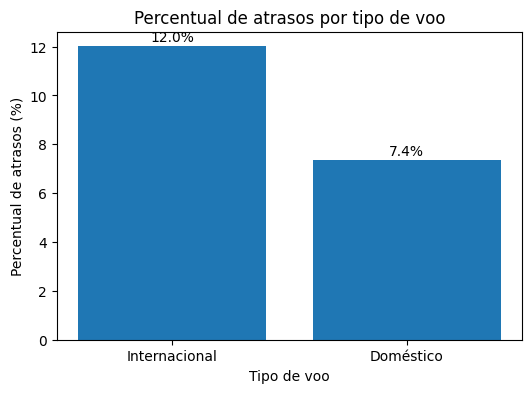

In [82]:
# Análise do percentual de atrasos por tipo de voo
analise_tipo_voo = (
    df.groupby('Tipo Voo')['atrasado']
      .agg(
          total_voos='count',
          total_atrasos='sum',
          percentual_atrasos='mean'
      )
      .reset_index()
)

analise_tipo_voo['percentual_atrasos'] *= 100

# Nome mais amigável
analise_tipo_voo['Tipo Voo'] = analise_tipo_voo['Tipo Voo'].replace({
    'I': 'Internacional',
    'N': 'Doméstico'
})

display(analise_tipo_voo)

# Gráfico
plt.figure(figsize=(6,4))

plt.bar(
    analise_tipo_voo['Tipo Voo'],
    analise_tipo_voo['percentual_atrasos']
)

plt.title('Percentual de atrasos por tipo de voo')
plt.xlabel('Tipo de voo')
plt.ylabel('Percentual de atrasos (%)')

for i, v in enumerate(analise_tipo_voo['percentual_atrasos']):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center')

plt.show()

#### 4.2 Análise 2 — Hora da partida

,periodo_dia,total_voos,total_atrasos,percentual_atrasos
0,Madrugada,25935,1627,6.273376
1,Manhã,71382,3815,5.344485
3,Tarde,73552,6754,9.182619
2,Noite,58910,6534,11.091496


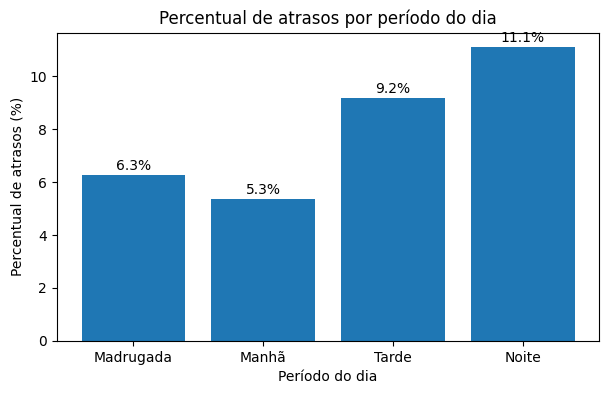

In [83]:
# Análise do percentual de atrasos por período do dia
analise_periodo = (
    df.groupby('periodo_dia')['atrasado']
      .agg(
          total_voos='count',
          total_atrasos='sum',
          percentual_atrasos='mean'
      )
      .reset_index()
)

analise_periodo['percentual_atrasos'] *= 100

# Mantém os períodos em ordem cronológica
ordem = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
analise_periodo['periodo_dia'] = pd.Categorical(
    analise_periodo['periodo_dia'],
    categories=ordem,
    ordered=True
)

analise_periodo = analise_periodo.sort_values('periodo_dia')

display(analise_periodo)

# Gráfico
plt.figure(figsize=(7,4))

plt.bar(
    analise_periodo['periodo_dia'],
    analise_periodo['percentual_atrasos']
)

plt.title('Percentual de atrasos por período do dia')
plt.xlabel('Período do dia')
plt.ylabel('Percentual de atrasos (%)')

for i, v in enumerate(analise_periodo['percentual_atrasos']):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center')

plt.show()

#### 4.3 Análise 3 - Modelo da Aeronave

,Modelo aeronave,total_voos,total_atrasos,percentual_atrasos
0,A20N,23860,2455,10.289187
8,E195,14125,1304,9.231858
4,AT76,15168,1387,9.144251
9,E295,17020,1551,9.112808
3,A321,19633,1586,8.078236
7,B738,30423,1996,6.560826
2,A320,40326,2558,6.343302
5,B38M,24472,1200,4.903563
1,A319,10733,492,4.583993
6,B737,6196,205,3.308586


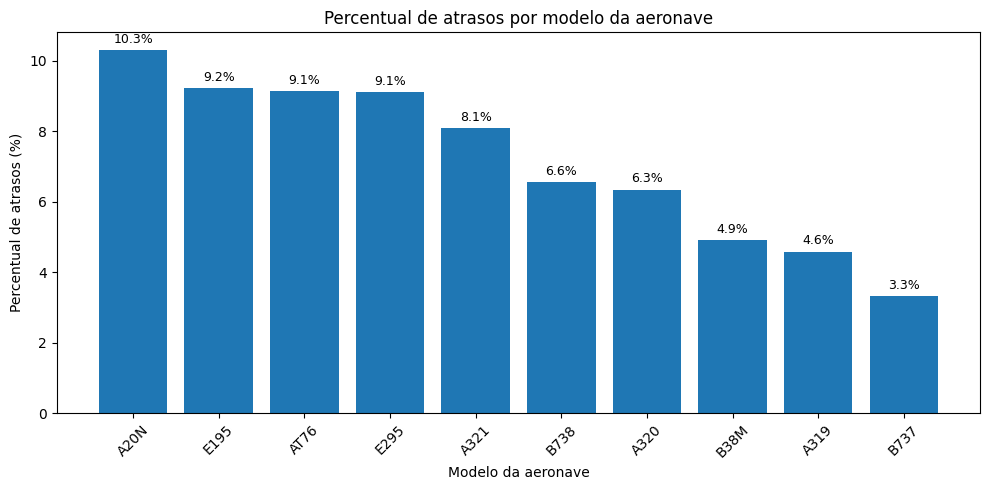

In [84]:
# Seleciona os 10 modelos de aeronave mais frequentes
top_modelos = df['Modelo aeronave'].value_counts().head(10).index

# Calcula o percentual de atrasos para esses modelos
analise_modelo = (
    df[df['Modelo aeronave'].isin(top_modelos)]
      .groupby('Modelo aeronave')['atrasado']
      .agg(
          total_voos='count',
          total_atrasos='sum',
          percentual_atrasos='mean'
      )
      .reset_index()
)

analise_modelo['percentual_atrasos'] *= 100

# Ordena do maior para o menor percentual de atrasos
analise_modelo = analise_modelo.sort_values(
    by='percentual_atrasos',
    ascending=False
)

display(analise_modelo)

# Gráfico
plt.figure(figsize=(10,5))

plt.bar(
    analise_modelo['Modelo aeronave'],
    analise_modelo['percentual_atrasos']
)

plt.title('Percentual de atrasos por modelo da aeronave')
plt.xlabel('Modelo da aeronave')
plt.ylabel('Percentual de atrasos (%)')
plt.xticks(rotation=45)

for i, v in enumerate(analise_modelo['percentual_atrasos']):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

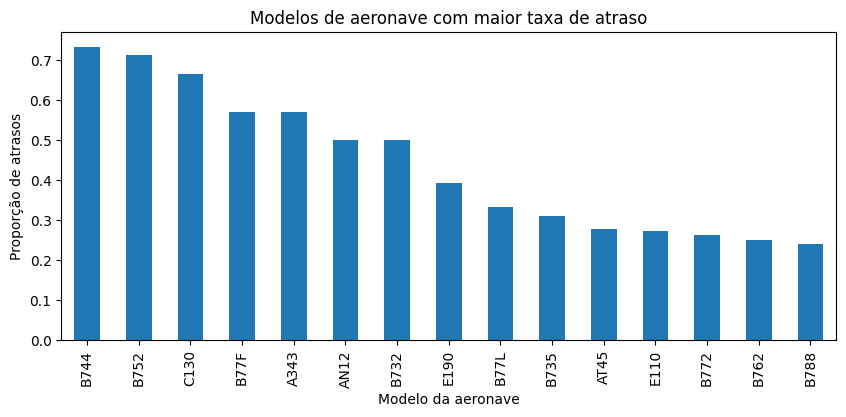

In [ ]:
import matplotlib.pyplot as plt

modelo_atraso.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Modelos de aeronave com maior taxa de atraso')
plt.ylabel('Proporção de atrasos')
plt.xlabel('Modelo da aeronave')

plt.show()

Na Parte I foi realizada uma análise mais detalhada da distribuição de frequência das categorias presentes nos atributos, com o objetivo de identificar possíveis classes pouco representadas que pudessem comprometer a interpretação dos resultados.

Como essa avaliação não motivou a remoção ou agrupamento de categorias e a estratégia de preparação dos dados permanece a mesma nesta segunda etapa, essa análise não será repetida.

### **5. Preparação para Modelagem**

#### 5.1 Definição de x e y


In [85]:
# Definição das variáveis preditoras
X = df[
    [
        'Sigla Aerea',
        'Modelo aeronave',
        'Assentos',
        'Origem',
        'Destino',
        'hora_partida',
        'minuto_partida',
        'dia_semana',
        'mes',
        'internacional',
        'periodo_dia'
    ]
]

# Definição da variável-alvo
y = df['atrasado']

print(X.shape)
print(y.shape)

(229779, 11)
(229779,)


#### 5.2 One-Hot encoding

In [86]:
# Aplicação do One-Hot Encoding nas variáveis categóricas
X = pd.get_dummies(
    X,
    columns=[
        'Sigla Aerea',
        'Modelo aeronave',
        'Origem',
        'Destino',
        'periodo_dia'
    ],
    drop_first=True
)

print(X.shape)

X.head()

(229779, 614)


,Assentos,hora_partida,minuto_partida,dia_semana,mes,internacional,Sigla Aerea_ABJ,Sigla Aerea_ACA,Sigla Aerea_ACN,Sigla Aerea_AEA,...,Destino_TJSJ,Destino_TLPL,Destino_TNCA,Destino_TNCC,Destino_TTPP,Destino_ZBAA,Destino_ZBTJ,periodo_dia_Manhã,periodo_dia_Noite,periodo_dia_Tarde
0,295,23,55,2,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,295,1,10,2,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,318,0,30,2,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,288,23,50,2,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,318,20,50,2,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


#### 5.3 Divisão de dados


In [87]:
from sklearn.model_selection import train_test_split

# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Treino: {X_train.shape[0]:,} registros")
print(f"Teste:  {X_test.shape[0]:,} registros")

Treino: 183,823 registros
Teste:  45,956 registros


### **6. Modelo baseline**


In [88]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

baseline = DummyClassifier(
    strategy='most_frequent'
)

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

In [89]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_baseline)
)

Accuracy: 0.9184872486726434


In [90]:
confusion_matrix(
    y_test,
    y_pred_baseline
)

array([[42210,     0],
       [ 3746,     0]])

In [91]:
print(
    classification_report(
        y_test,
        y_pred_baseline
    )
)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42210
           1       0.00      0.00      0.00      3746

    accuracy                           0.92     45956
   macro avg       0.46      0.50      0.48     45956
weighted avg       0.84      0.92      0.88     45956



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


O modelo baseline apresentou acurácia de aproximadamente 91,8%, valor semelhante ao observado na Parte I. Entretanto, a análise da matriz de confusão demonstra que o modelo continua prevendo exclusivamente a classe majoritária (voos sem atraso), não sendo capaz de identificar nenhum voo atrasado.

Esse comportamento evidencia que, apesar da inclusão de novos atributos na Parte II, um modelo que não aprende padrões dos dados continua incapaz de representar adequadamente o problema. Dessa forma, as métricas Precision, Recall e F1-Score serão novamente utilizadas para avaliar se os modelos de Machine Learning conseguem explorar as novas informações adicionadas ao conjunto de dados.

### **7. Logistic Regression**
Após o modelo baseline, foi treinado um modelo de **Regressão Logística**, mantendo a mesma lógica utilizada na Parte I.

Como a Regressão Logística é sensível à escala das variáveis, os dados foram previamente padronizados com o `StandardScaler`. A padronização foi ajustada apenas com os dados de treino e depois aplicada ao conjunto de teste, evitando vazamento de dados.

#### 7.1 Padronização das Variáveis


In [99]:
# Cópia dos dados para a Regressão Logística
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

colunas_numericas = [
    'Assentos',
    'hora_partida',
    'minuto_partida',
    'dia_semana',
    'mes'
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr[colunas_numericas] = scaler.fit_transform(
    X_train_lr[colunas_numericas]
)

X_test_lr[colunas_numericas] = scaler.transform(
    X_test_lr[colunas_numericas]
)

X_train_lr[colunas_numericas].describe()

,Assentos,hora_partida,minuto_partida,dia_semana,mes
count,1.838230e+05,1.838230e+05,1.838230e+05,1.838230e+05,1.838230e+05
mean,-2.563509e-16,-1.204061e-16,7.661151e-17,8.171379e-17,-1.729750e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-2.916698e+00,-2.186847e+00,-1.502908e+00,-1.500047e+00,-1.175486e+00
25%,-5.732568e-01,-8.288405e-01,-9.357459e-01,-9.966430e-01,-1.175486e+00
50%,1.399646e-01,1.991321e-02,-8.500316e-02,1.016541e-02,3.067517e-02
75%,2.418534e-01,8.686669e-01,7.657396e-01,1.016974e+00,1.236836e+00
max,5.828754e+00,1.717421e+00,1.843347e+00,1.520378e+00,2.442997e+00


#### 7.2 Treinamento do modelo

Utilizamos os hiperparâmetros escolhidos na otimização da parte I deste trabalho.

In [120]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    C=10,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(X_train_lr, y_train)

y_pred_lr = modelo_lr.predict(X_test_lr)

#### 7.3 Teste do modelo

In [121]:
y_pred_lr = modelo_lr.predict(X_test_lr)

#### 7.4 Matriz de confusão

In [122]:
confusion_matrix(
    y_test,
    y_pred_lr
)

array([[27240, 14970],
       [ 1420,  2326]])

In [123]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.95      0.65      0.77     42210
           1       0.13      0.62      0.22      3746

    accuracy                           0.64     45956
   macro avg       0.54      0.63      0.49     45956
weighted avg       0.88      0.64      0.72     45956



#### 7.5. Comparação dos resultados

Nesta segunda etapa, optou-se por utilizar diretamente essa mesma configuração, sem realizar uma nova otimização. Essa decisão tem como objetivo manter a consistência metodológica entre as duas partes do trabalho, permitindo que as diferenças observadas no desempenho do modelo sejam atribuídas principalmente ao enriquecimento do conjunto de dados, e não a alterações nos hiperparâmetros do algoritmo.

A Regressão Logística apresentou desempenho bastante semelhante ao obtido na Parte I. Comparando os resultados, observa-se uma pequena redução na acurácia (de aproximadamente 68% para 64%) e na precisão da classe atrasado (de 15% para 13%). Em contrapartida, o modelo apresentou um leve aumento no Recall da classe minoritária (de 60% para 62%), indicando que conseguiu identificar uma quantidade ligeiramente maior de voos atrasados.

Entretanto, essa melhora no Recall não foi suficiente para compensar a redução na Precision, resultando em uma pequena queda no F1-Score da classe atrasado (de 0,24 para 0,22). Esses resultados indicam que, embora o conjunto de dados tenha sido enriquecido com novas informações operacionais, a Regressão Logística não conseguiu explorar essas variáveis de forma a produzir ganhos significativos de desempenho.

Esse comportamento sugere que as novas variáveis introduzem relações mais complexas entre os atributos e a ocorrência de atrasos, as quais podem não ser adequadamente representadas por um modelo linear.

### **8. Random Forest**

#### 8.1 Treinamento do modelo

In [125]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_jobs=-1,
                       random_state=42)

#### 8.2 Teste do modelo

In [126]:
y_pred_rf = modelo_rf.predict(X_test)

#### 8.3 Matriz de confusão

In [127]:
confusion_matrix(
    y_test,
    y_pred_rf
)

array([[31390, 10820],
       [ 1824,  1922]])

In [128]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.95      0.74      0.83     42210
           1       0.15      0.51      0.23      3746

    accuracy                           0.72     45956
   macro avg       0.55      0.63      0.53     45956
weighted avg       0.88      0.72      0.78     45956



A Random Forest foi treinada utilizando a mesma configuração de hiperparâmetros adotada na Parte I, permitindo que a comparação entre os resultados refletisse exclusivamente o impacto do enriquecimento do conjunto de dados.

Comparando os resultados obtidos nas duas etapas, observa-se uma mudança no comportamento do modelo em relação às duas classes. Para a classe sem atraso, houve um pequeno aumento na Precision (de 0,93 para 0,95), porém acompanhado de redução no Recall (de 0,86 para 0,74) e no F1-Score (de 0,90 para 0,83). Isso indica que o modelo passou a ser mais conservador ao classificar voos como pontuais.

Para a classe atrasado, verificou-se uma pequena redução na Precision (de 0,18 para 0,15), indicando aumento na quantidade de falsos positivos. Em contrapartida, o Recall apresentou uma melhora expressiva, passando de 0,31 para 0,51, o que significa que o modelo conseguiu identificar uma parcela significativamente maior dos voos atrasados.

Apesar dessas mudanças, o F1-Score da classe atrasado permaneceu praticamente inalterado (0,23 em ambas as etapas), indicando que o ganho obtido no Recall foi compensado pela redução na Precision. Em outras palavras, o enriquecimento da base tornou o modelo mais sensível para detectar atrasos, porém sem melhorar o equilíbrio geral entre precisão e cobertura dessa classe.

Como o objetivo deste trabalho é prever a ocorrência de atrasos, o aumento do Recall representa um resultado relevante, pois reduz a quantidade de voos atrasados não identificados pelo modelo. Entretanto, o F1-Score mostra que ainda há espaço para melhorar esse desempenho, motivando a avaliação do XGBoost na sequência deste trabalho.

### **9. XGBoost**
#### 9.1 Treinamento do modelo

In [129]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    scale_pos_weight=5,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

modelo_xgb.fit(
    X_train,
    y_train
)

y_pred_xgb = modelo_xgb.predict(X_test)

#### 9.2 Matriz de confusão

In [130]:
confusion_matrix(
    y_test,
    y_pred_xgb
)

array([[40341,  1869],
       [ 3031,   715]])

In [131]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     42210
           1       0.28      0.19      0.23      3746

    accuracy                           0.89     45956
   macro avg       0.60      0.57      0.58     45956
weighted avg       0.88      0.89      0.88     45956



Assim como nos modelos anteriores, o XGBoost foi treinado utilizando exatamente os mesmos hiperparâmetros definidos na Parte I, permitindo que a comparação entre os resultados refletisse apenas o impacto do enriquecimento do conjunto de dados.

Comparando as duas etapas, observa-se que a Accuracy permaneceu praticamente inalterada, em aproximadamente 89%, indicando que o desempenho global do modelo foi mantido. Para a classe sem atraso, as métricas também permaneceram estáveis, com pequeno aumento no Recall (de 0,94 para 0,96) e manutenção do F1-Score em 0,94.

Para a classe atrasado, entretanto, verificou-se uma redução em todas as métricas. A Precision diminuiu de 0,31 para 0,28, o Recall caiu de 0,27 para 0,19 e, consequentemente, o F1-Score foi reduzido de 0,29 para 0,23.

Esses resultados indicam que, diferentemente da expectativa inicial, o enriquecimento do conjunto de dados não produziu ganhos para o XGBoost. Embora o modelo tenha mantido seu excelente desempenho na identificação dos voos sem atraso, sua capacidade de identificar corretamente a classe minoritária foi reduzida. Isso sugere que as novas variáveis adicionadas nesta etapa não forneceram informações discriminativas suficientes para melhorar a predição dos atrasos nessa configuração do algoritmo.

# **Conclusões gerais**
Embora os modelos tenham sido capazes de identificar parte dos padrões presentes na base de dados, os resultados mostraram que as informações disponíveis antes da decolagem não foram suficientes para prever, com elevada confiabilidade, quais voos efetivamente sofreriam atraso na chegada.

A análise dos resultados evidencia que o problema é mais complexo do que inicialmente se imaginava. Diversos fatores que influenciam a ocorrência de atrasos, como condições meteorológicas, congestionamento do espaço aéreo, indisponibilidade de infraestrutura aeroportuária, atrasos acumulados ao longo da malha aérea e decisões operacionais das companhias, não estavam representados no conjunto de dados utilizado. Dessa forma, mesmo com a inclusão de novas variáveis operacionais na segunda etapa do trabalho, os ganhos obtidos foram limitados, indicando que os atributos disponíveis não capturam toda a complexidade do fenômeno estudado.

Esse resultado reforça uma importante característica de projetos de Ciência de Dados: o desempenho de um modelo depende não apenas do algoritmo utilizado, mas principalmente da qualidade, relevância e capacidade explicativa dos dados disponíveis. Modelos mais sofisticados não conseguem compensar a ausência de informações fundamentais para descrever o processo que se deseja prever.

Assim, conclui-se que a previsão de atrasos em voos é um problema multifatorial, cuja solução demanda a integração de fontes de dados adicionais e mais representativas da operação aérea. Informações como condições meteorológicas, fluxo de tráfego aéreo, histórico de atrasos das aeronaves, tempo de solo, disponibilidade de pistas e fatores operacionais das companhias aéreas provavelmente contribuiriam de forma significativa para aumentar a capacidade preditiva dos modelos. Dessa forma, o trabalho demonstra não apenas a aplicação prática das técnicas de Machine Learning, mas também a importância da compreensão do domínio do problema e da seleção adequada dos dados para o desenvolvimento de soluções preditivas robustas.